
# Índice de Riesgo Climático para Café

Este notebook construye un índice climático de riesgo por clúster a partir de:

- `features_intra_anuales_2007-2024_clusters.csv`
- variables intra-anuales seleccionadas previamente
- modelo Ridge por clúster
- coeficientes calibrados por régimen climático

El objetivo es obtener un índice operativo para evaluar riesgo asociado al rendimiento.


## 1. Librerías

In [24]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error


In [27]:
import os
os.chdir('..')
print(os.getcwd())

C:\Users\nbellon\Documents\GitHub


## 2. Rutas y carga de datos

In [34]:

PROJECT_ROOT = Path().resolve()
path = PROJECT_ROOT /"proyecto_aplicado_en_analitica_de_datos" / "data" / "processed"

archivo = path / "features_intra_anuales_2007-2024_clusters.csv"

df_model = pd.read_csv(archivo)

df_model.head()


,municipio,date,anio,Área sembrada (ha),Rendimiento (t/ha),produccion_t,precip_mm_sum,precip_mm_mean,precip_mm_std,precip_mm_min,...,balance_hidrico_mm_z_mean_anual,balance_hidrico_mm_z_min_anual,balance_hidrico_mm_z_max_anual,deficit_hidrico_mm_z_mean_anual,deficit_hidrico_mm_z_min_anual,deficit_hidrico_mm_z_max_anual,exceso_hidrico_mm_z_mean_anual,exceso_hidrico_mm_z_min_anual,exceso_hidrico_mm_z_max_anual,cluster
0,Aguadas,2007-12-31,2007,4626.0,0.97,4063.0,2660.352575,221.696048,106.472932,39.417551,...,0.343023,-1.319420,1.425035,0.131243,-0.618179,3.480916,0.361895,-1.220112,1.425035,1
1,Anserma,2007-12-31,2007,7125.0,1.30,7131.0,2168.859973,180.738331,79.863766,26.391460,...,0.167279,-1.394092,1.550450,0.116148,-0.664257,3.258719,0.174870,-1.054646,1.550450,2
2,Aranzazu,2007-12-31,2007,2597.0,1.01,2254.0,2106.546668,175.545556,91.258936,35.359744,...,0.170433,-1.729506,1.957977,0.527726,-0.761310,3.874084,0.227237,-1.051529,1.934536,1
3,Belalcázar,2007-12-31,2007,3734.0,1.20,3835.0,2429.582959,202.465247,85.739394,37.993671,...,0.300368,-1.070850,1.321184,0.093395,-0.684778,3.236328,0.293302,-0.995501,1.367424,2
4,Chinchiná,2007-12-31,2007,5632.0,1.63,9203.0,2530.997565,210.916464,83.768437,58.426388,...,0.109842,-1.212987,1.222853,0.264114,-0.529252,3.675252,0.115842,-1.208808,1.262900,2


## 3. Validaciones iniciales

In [35]:

target = "Rendimiento (t/ha)"

cols_base = ["municipio", "anio", "cluster", target]
faltantes_base = [c for c in cols_base if c not in df_model.columns]

if faltantes_base:
    raise ValueError(f"Faltan columnas base necesarias: {faltantes_base}")

print("Columnas base disponibles")
print(df_model[cols_base].head())


Columnas base disponibles
    municipio  anio  cluster  Rendimiento (t/ha)
0     Aguadas  2007        1                0.97
1     Anserma  2007        2                1.30
2    Aranzazu  2007        1                1.01
3  Belalcázar  2007        2                1.20
4   Chinchiná  2007        2                1.63


## 4. Variables finales del índice

In [36]:

vars_cluster = [
    "et_real_mm_std",
    "et_potencial_mm_std",
    "ndvi_mean_m05",
    "exceso_hidrico_mm_m02",
    "temp_max_max_m04_06",
    "balance_hidrico_mm_min_m01_06",
    "ndvi_mean_min_m01_06",
    "precip_max_mm_m07"
]

faltantes_vars = [v for v in vars_cluster if v not in df_model.columns]

if faltantes_vars:
    raise ValueError(f"Faltan variables del índice: {faltantes_vars}")

print("Variables del índice disponibles")


Variables del índice disponibles



## 5. Ajuste del modelo Ridge por clúster

En este bloque se recalculan los coeficientes del modelo por clúster.  
Esto es necesario porque este notebook es independiente y no hereda variables del notebook de selección.


In [37]:

coeficientes = {}
resultados_modelo = []

for c in sorted(df_model["cluster"].dropna().unique()):

    df_c = df_model[df_model["cluster"] == c].copy()

    X_c = df_c[vars_cluster]
    y_c = df_c[target]

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ])

    # Validación cruzada flexible según tamaño del clúster
    n_obs = len(df_c)
    cv = min(5, n_obs)

    if cv >= 3:
        scores = cross_val_score(pipeline, X_c, y_c, cv=cv, scoring="r2")
        r2_cv = scores.mean()
    else:
        r2_cv = np.nan

    # Ajuste final sobre todo el clúster
    pipeline.fit(X_c, y_c)
    y_pred = pipeline.predict(X_c)

    r2_train = r2_score(y_c, y_pred)
    mae_train = mean_absolute_error(y_c, y_pred)

    coef = pd.Series(
        pipeline.named_steps["model"].coef_,
        index=vars_cluster
    ).sort_values(key=abs, ascending=False)

    coeficientes[c] = coef

    resultados_modelo.append({
        "cluster": c,
        "n_obs": n_obs,
        "r2_cv": r2_cv,
        "r2_train": r2_train,
        "mae_train": mae_train
    })

resultados_modelo = pd.DataFrame(resultados_modelo)
resultados_modelo


,cluster,n_obs,r2_cv,r2_train,mae_train
0,0,36,-3.650372,0.086728,0.189669
1,1,162,-0.224740,0.163169,0.206214
2,2,198,-0.267925,0.129850,0.182128
3,3,54,-1.102603,0.416179,0.110268


## 6. Coeficientes por clúster

In [38]:

for c, coef in coeficientes.items():
    print(f"\nCluster {c}")
    print(coef)



Cluster 0
ndvi_mean_m05                   -0.063405
balance_hidrico_mm_min_m01_06   -0.058696
precip_max_mm_m07               -0.046407
ndvi_mean_min_m01_06             0.037433
exceso_hidrico_mm_m02            0.026910
et_potencial_mm_std              0.021235
et_real_mm_std                  -0.015602
temp_max_max_m04_06              0.007087
dtype: float64

Cluster 1
et_potencial_mm_std              0.107411
et_real_mm_std                  -0.066673
temp_max_max_m04_06              0.048003
ndvi_mean_m05                    0.042064
ndvi_mean_min_m01_06             0.028381
balance_hidrico_mm_min_m01_06   -0.019302
exceso_hidrico_mm_m02            0.014097
precip_max_mm_m07               -0.007680
dtype: float64

Cluster 2
temp_max_max_m04_06              0.049114
et_potencial_mm_std              0.046056
precip_max_mm_m07                0.042655
ndvi_mean_m05                    0.038343
et_real_mm_std                  -0.030977
exceso_hidrico_mm_m02           -0.019841
balance_hidri


## 7. Construcción del índice climático calibrado por clúster

El índice se calcula así:

1. Se estandarizan las variables dentro de cada clúster.
2. Se ponderan usando los coeficientes Ridge del clúster.
3. Se suma el aporte ponderado de cada variable.


In [39]:

df_model["indice_cluster_raw"] = np.nan

for c in sorted(df_model["cluster"].dropna().unique()):

    df_c = df_model[df_model["cluster"] == c].copy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_c[vars_cluster])
    X_scaled = pd.DataFrame(
        X_scaled,
        columns=vars_cluster,
        index=df_c.index
    )

    pesos = coeficientes[c].loc[vars_cluster]

    indice = X_scaled.mul(pesos, axis=1).sum(axis=1)

    df_model.loc[df_c.index, "indice_cluster_raw"] = indice

df_model[["municipio", "anio", "cluster", target, "indice_cluster_raw"]].head()


,municipio,anio,cluster,Rendimiento (t/ha),indice_cluster_raw
0,Aguadas,2007,1,0.97,0.065213
1,Anserma,2007,2,1.30,-0.041384
2,Aranzazu,2007,1,1.01,-0.050774
3,Belalcázar,2007,2,1.20,0.084197
4,Chinchiná,2007,2,1.63,0.043257



## 8. Normalización del índice

Se normaliza el índice dentro de cada clúster para que sea comparable en términos relativos.


In [40]:

df_model["indice_cluster"] = np.nan

for c in sorted(df_model["cluster"].dropna().unique()):

    idx = df_model["cluster"] == c
    media = df_model.loc[idx, "indice_cluster_raw"].mean()
    std = df_model.loc[idx, "indice_cluster_raw"].std()

    df_model.loc[idx, "indice_cluster"] = (
        df_model.loc[idx, "indice_cluster_raw"] - media
    ) / std

df_model[["municipio", "anio", "cluster", target, "indice_cluster"]].head()


,municipio,anio,cluster,Rendimiento (t/ha),indice_cluster
0,Aguadas,2007,1,0.97,0.528465
1,Anserma,2007,2,1.30,-0.416760
2,Aranzazu,2007,1,1.01,-0.411458
3,Belalcázar,2007,2,1.20,0.847915
4,Chinchiná,2007,2,1.63,0.435625


## 9. Validación visual del índice

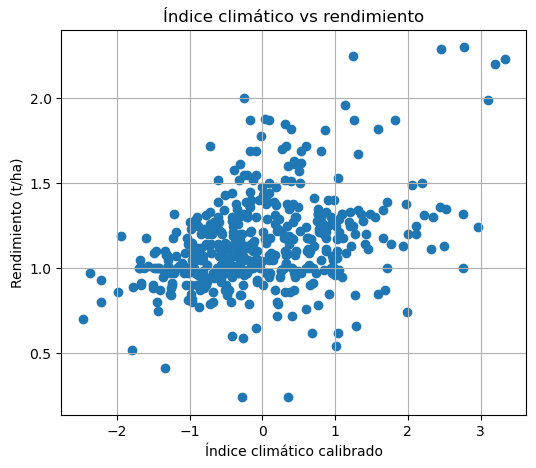

In [41]:

plt.figure(figsize=(6, 5))
plt.scatter(df_model["indice_cluster"], df_model[target])
plt.xlabel("Índice climático calibrado")
plt.ylabel(target)
plt.title("Índice climático vs rendimiento")
plt.grid()
plt.show()


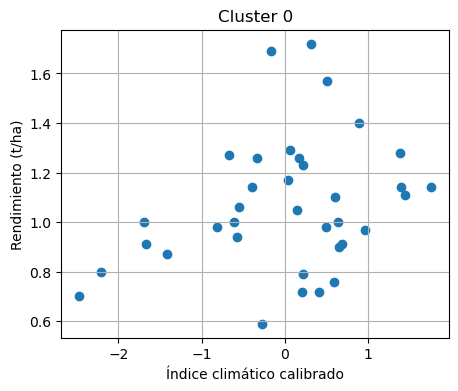

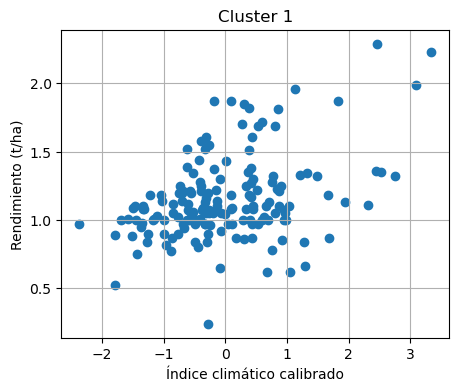

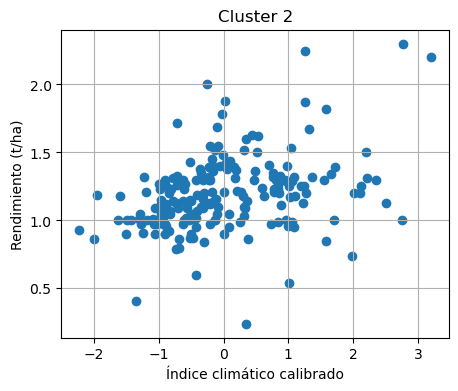

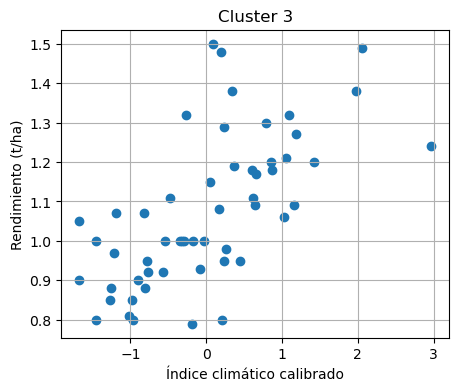

In [42]:

for c in sorted(df_model["cluster"].dropna().unique()):

    df_c = df_model[df_model["cluster"] == c]

    plt.figure(figsize=(5, 4))
    plt.scatter(df_c["indice_cluster"], df_c[target])
    plt.xlabel("Índice climático calibrado")
    plt.ylabel(target)
    plt.title(f"Cluster {c}")
    plt.grid()
    plt.show()



## 10. Definición de evento de pérdida

Se define evento de pérdida como rendimiento por debajo del percentil 30.  
Este umbral puede ajustarse posteriormente según criterios actuariales o comerciales.


In [43]:

p30_global = df_model[target].quantile(0.30)

df_model["evento_perdida_global"] = (
    df_model[target] <= p30_global
).astype(int)

print("P30 global rendimiento:", p30_global)
df_model["evento_perdida_global"].value_counts()


P30 global rendimiento: 1.0


evento_perdida_global
0    298
1    152
Name: count, dtype: int64


## 11. Umbral de riesgo por índice

Como el índice está orientado a rendimiento esperado, valores bajos del índice deberían asociarse con mayor riesgo.


In [44]:

p30_indice = df_model["indice_cluster"].quantile(0.30)

df_model["riesgo_indice"] = np.where(
    df_model["indice_cluster"] <= p30_indice,
    "Alto",
    "No alto"
)

pd.crosstab(
    df_model["riesgo_indice"],
    df_model["evento_perdida_global"],
    margins=True
)


evento_perdida_global,0,1,All
riesgo_indice,,,
Alto,66,69,135
No alto,232,83,315
All,298,152,450


## 12. Clasificación en tres niveles de riesgo

In [45]:

q30 = df_model["indice_cluster"].quantile(0.30)
q70 = df_model["indice_cluster"].quantile(0.70)

def clasificar_riesgo(x):
    if x <= q30:
        return "Alto"
    elif x <= q70:
        return "Medio"
    else:
        return "Bajo"

df_model["riesgo"] = df_model["indice_cluster"].apply(clasificar_riesgo)

df_model["riesgo"].value_counts()


riesgo
Medio    180
Bajo     135
Alto     135
Name: count, dtype: int64

## 13. Rendimiento promedio por nivel de riesgo

In [46]:

resumen_riesgo = (
    df_model
    .groupby("riesgo")
    .agg(
        n=("riesgo", "size"),
        rendimiento_promedio=(target, "mean"),
        rendimiento_mediano=(target, "median"),
        indice_promedio=("indice_cluster", "mean"),
        tasa_evento_perdida=("evento_perdida_global", "mean")
    )
    .reset_index()
)

resumen_riesgo


,riesgo,n,rendimiento_promedio,rendimiento_mediano,indice_promedio,tasa_evento_perdida
0,Alto,135,1.030593,1.000,-1.068628,0.511111
1,Bajo,135,1.246370,1.210,1.199106,0.222222
2,Medio,180,1.172944,1.135,-0.097858,0.294444


### Interpretación
Se aprecia una diferenciación de índice, que relaciona el rendimiento del cultivo con respecto a las variables climáticas de interés generando el siguiente resultado:  

| Riesgo | Rendimiento prom | Pérdida |
|--------|------------------|---------|
| Bajo   |      1.17        | 22%     |
| Medio  |      1.25        | 29%     |
| Alto   |      1.03        | 51%     |   

* Monoticidad
* Separación
* Relación Riesgo --> Rendimiento


## 14. Guardar resultados

In [47]:

salida_indice = path / "indice_riesgo_climatico_2007-2024.csv"
salida_coef = path / "coeficientes_indice_por_cluster.csv"
salida_modelo = path / "metricas_modelo_indice_por_cluster.csv"

df_model.to_csv(salida_indice, index=False)

coeficientes_df = (
    pd.DataFrame(coeficientes)
    .reset_index()
    .rename(columns={"index": "variable"})
)

coeficientes_df.to_csv(salida_coef, index=False)
resultados_modelo.to_csv(salida_modelo, index=False)

print("Archivos guardados:")
print(salida_indice)
print(salida_coef)
print(salida_modelo)

Archivos guardados:
C:\Users\nbellon\Documents\GitHub\proyecto_aplicado_en_analitica_de_datos\data\processed\indice_riesgo_climatico_2007-2024.csv
C:\Users\nbellon\Documents\GitHub\proyecto_aplicado_en_analitica_de_datos\data\processed\coeficientes_indice_por_cluster.csv
C:\Users\nbellon\Documents\GitHub\proyecto_aplicado_en_analitica_de_datos\data\processed\metricas_modelo_indice_por_cluster.csv


## Índice de pago

In [48]:
# Trigger - ¿Cuándo pagar el seguro?
# trigger = df_model["indice_cluster"].quantile(0.30)
# q30 = indice.quantile(0.30)

In [49]:
y_true = df_model["evento_perdida_global"]
indice = df_model["indice_cluster"]

In [50]:
umbrales = np.linspace(indice.min(), indice.max(), 100)

resultados = []

for t in umbrales:
    
    pred = (indice <= t).astype(int)
    
    TP = ((y_true == 1) & (pred == 1)).sum()
    TN = ((y_true == 0) & (pred == 0)).sum()
    FP = ((y_true == 0) & (pred == 1)).sum()
    FN = ((y_true == 1) & (pred == 0)).sum()
    
    TPR = TP / (TP + FN)   # sensibilidad
    FPR = FP / (FP + TN)   # falso positivo
    
    resultados.append({
        "threshold": t,
        "TPR": TPR,
        "FPR": FPR,
        "FN_rate": FN / len(df_model),
        "FP_rate": FP / len(df_model)
    })

df_eval = pd.DataFrame(resultados)

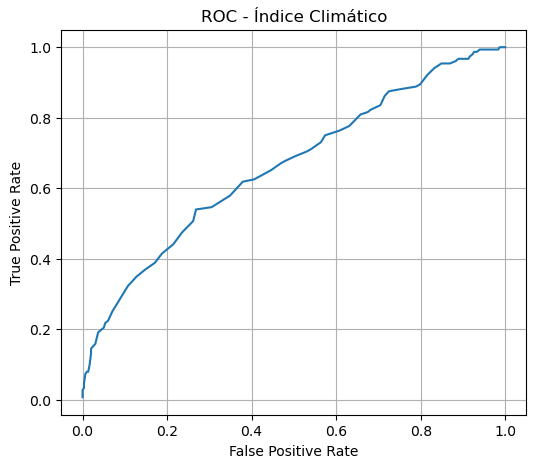

In [51]:
plt.figure(figsize=(6,5))
plt.plot(df_eval["FPR"], df_eval["TPR"])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC - Índice Climático")
plt.grid()
plt.show()

In [52]:
# Cálculo de AUC
from sklearn.metrics import auc
auc_value = auc(df_eval["FPR"], df_eval["TPR"])
print(f"AUC: {auc_value:.4f}")

AUC: 0.6629


In [53]:
# Selección óptima del Trigger
df_eval["score"] = df_eval["FN_rate"] * 2 + df_eval["FP_rate"]

best = df_eval.loc[df_eval["score"].idxmin()]

trigger = best["threshold"]

print("Trigger óptimo:", trigger)

Trigger óptimo: -0.4193530694660019


In [54]:
# Validación
df_eval["youden"] = df_eval["TPR"] - df_eval["FPR"]
trigger = df_eval.loc[df_eval["youden"].idxmax(), "threshold"]

In [55]:
# Pérdida severa (límite inferior)
limite = df_model.loc[
    df_model["evento_perdida_global"] == 1,
    "indice_cluster"
].quantile(0.1)

print("Límite:", limite)

Límite: -1.4587754726186755


In [56]:
def payout(indice, trigger, limite):
    
    if indice >= trigger:
        return 0
    
    elif indice <= limite:
        return 1
    
    else:
        x = (trigger - indice) / (trigger - limite)
        return x**1.3                                 # Ajuste de prima por severidad (0 (muy laxo) 1.5 (Muy severo))

In [57]:
df_model["payout"] = df_model["indice_cluster"].apply(
    lambda x: payout(x, trigger, limite)
)

In [58]:
# Ajuste por clúster (Pago diferencial por región)
prima_cluster = df_model.groupby("cluster")["payout"].mean() 

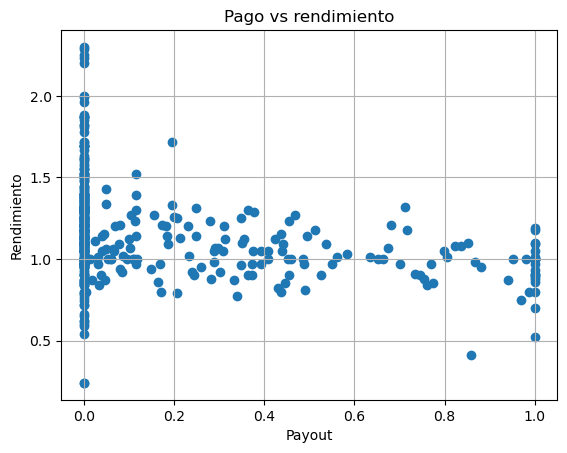

In [59]:
# Pago vs. Rendimiento
plt.scatter(df_model["payout"], df_model["Rendimiento (t/ha)"])
plt.xlabel("Payout")
plt.ylabel("Rendimiento")
plt.title("Pago vs rendimiento")
plt.grid()
plt.show()

In [60]:
# Pago promedio
df_model["payout"].mean()

0.15586350881379468

In [61]:
# Pago en pérdida
df_model.loc[df_model["evento_perdida_global"] == 1, "payout"].mean()

0.27427182520766175

In [62]:
# Pago sin pérdida
df_model.loc[df_model["evento_perdida_global"] == 0, "payout"].mean()

0.09546732058605041

In [63]:
# Efectividad del seguro
efectividad = (
    df_model.loc[df_model["evento_perdida_global"] == 1, "payout"].mean()
    -
    df_model.loc[df_model["evento_perdida_global"] == 0, "payout"].mean()
)

print("Separación del seguro:", efectividad)

Separación del seguro: 0.17880450462161135


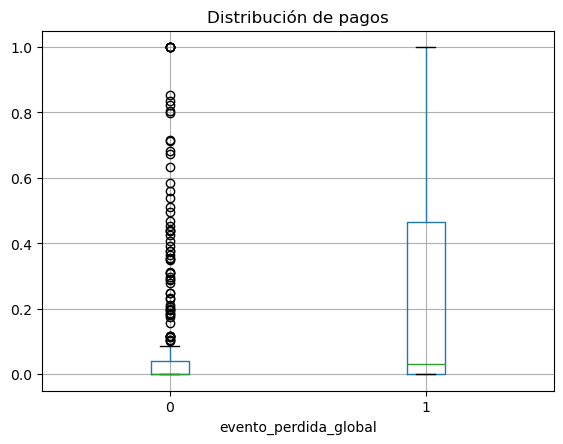

In [64]:
df_model.boxplot(column="payout", by="evento_perdida_global")
plt.title("Distribución de pagos")
plt.suptitle("")
plt.show()

In [65]:
prima = df_model["payout"].mean()
print("Prima pura:", prima)

margen = 0.30

prima_comercial = prima * (1 + margen)
print("Prima comercial:", prima_comercial)


Prima pura: 0.15586350881379468
Prima comercial: 0.2026225614579331


### Simulación del riesgo

In [66]:
# Supuestos económicos
valor_asegurado = 1.0                             # 1 = 100% del valor asegurado
margen = 0.30                                     # margen comercial / gastos / utilidad
prima_pura = df_model["payout"].mean()
prima_comercial = prima_pura * (1 + margen)

print("Prima pura:", prima_pura)
print("Prima comercial:", prima_comercial)

Prima pura: 0.15586350881379468
Prima comercial: 0.2026225614579331


In [67]:
# Ingreso por primas y egreso por pagos
df_model["prima_pura"] = prima_pura * valor_asegurado
df_model["prima_comercial"] = prima_comercial * valor_asegurado
df_model["indemnizacion"] = df_model["payout"] * valor_asegurado

df_model["resultado_puro"] = df_model["prima_pura"] - df_model["indemnizacion"]
df_model["resultado_comercial"] = df_model["prima_comercial"] - df_model["indemnizacion"]

df_model[[
    "municipio", "anio", "cluster", "Rendimiento (t/ha)",
    "indice_cluster", "riesgo", "payout",
    "prima_comercial", "indemnizacion", "resultado_comercial"
]].head(3)

,municipio,anio,cluster,Rendimiento (t/ha),indice_cluster,riesgo,payout,prima_comercial,indemnizacion,resultado_comercial
0,Aguadas,2007,1,0.97,0.528465,Bajo,0.0,0.202623,0.0,0.202623
1,Anserma,2007,2,1.30,-0.416760,Medio,0.0,0.202623,0.0,0.202623
2,Aranzazu,2007,1,1.01,-0.411458,Medio,0.0,0.202623,0.0,0.202623


In [68]:
# Resumen general del portafolio
resumen_portafolio = pd.DataFrame({
    "prima_pura_promedio": [df_model["prima_pura"].mean()],
    "prima_comercial_promedio": [df_model["prima_comercial"].mean()],
    "payout_promedio": [df_model["payout"].mean()],
    "indemnizacion_promedio": [df_model["indemnizacion"].mean()],
    "resultado_puro_promedio": [df_model["resultado_puro"].mean()],
    "resultado_comercial_promedio": [df_model["resultado_comercial"].mean()],
    "loss_ratio_puro": [df_model["indemnizacion"].sum() / df_model["prima_pura"].sum()],
    "loss_ratio_comercial": [df_model["indemnizacion"].sum() / df_model["prima_comercial"].sum()]
})

# resumen_portafolio

In [69]:
# Resultado anual del portafolio
resultado_anual = (
    df_model
    .groupby("anio")
    .agg(
        n=("anio", "size"),
        prima_total=("prima_comercial", "sum"),
        indemnizacion_total=("indemnizacion", "sum"),
        resultado_total=("resultado_comercial", "sum"),
        payout_promedio=("payout", "mean"),
        tasa_evento_perdida=("evento_perdida_global", "mean")
    )
    .reset_index()
)

resultado_anual["loss_ratio"] = (
    resultado_anual["indemnizacion_total"] /
    resultado_anual["prima_total"]
)

resultado_anual

,anio,n,prima_total,indemnizacion_total,resultado_total,payout_promedio,tasa_evento_perdida,loss_ratio
0,2007,25,5.065564,1.190070,3.875494,0.047603,0.28,0.234933
1,2008,25,5.065564,4.734477,0.331087,0.189379,0.40,0.934640
2,2009,25,5.065564,6.741056,-1.675492,0.269642,0.56,1.330761
3,2010,25,5.065564,1.063503,4.002061,0.042540,0.40,0.209948
4,2011,25,5.065564,3.707352,1.358212,0.148294,0.40,0.731874
5,2012,25,5.065564,7.007189,-1.941625,0.280288,0.88,1.383299
6,2013,25,5.065564,4.106772,0.958792,0.164271,0.76,0.810724
7,2014,25,5.065564,5.900151,-0.834587,0.236006,0.16,1.164757
8,2015,25,5.065564,8.049209,-2.983645,0.321968,0.08,1.589006
9,2016,25,5.065564,1.227187,3.838377,0.049087,0.08,0.242261


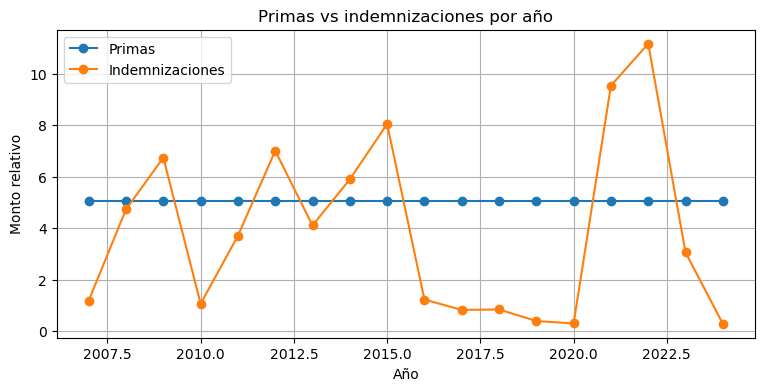

In [70]:
# Visualización del resultado anual
plt.figure(figsize=(9, 4))
plt.plot(resultado_anual["anio"], resultado_anual["prima_total"], marker="o", label="Primas")
plt.plot(resultado_anual["anio"], resultado_anual["indemnizacion_total"], marker="o", label="Indemnizaciones")
plt.xlabel("Año")
plt.ylabel("Monto relativo")
plt.title("Primas vs indemnizaciones por año")
plt.legend()
plt.grid()
plt.show()

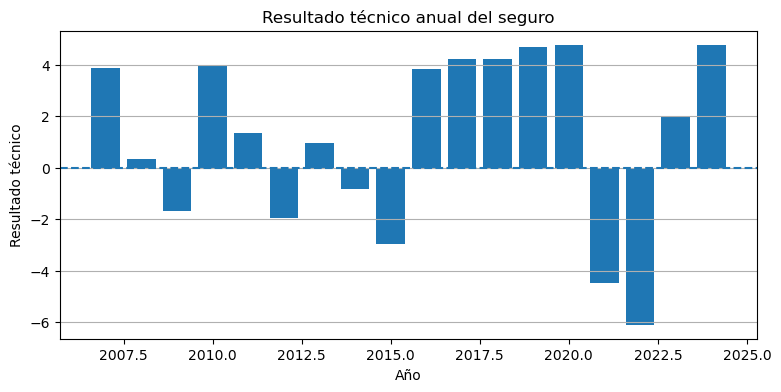

In [71]:
plt.figure(figsize=(9, 4))
plt.bar(resultado_anual["anio"], resultado_anual["resultado_total"])
plt.axhline(0, linestyle="--")
plt.xlabel("Año")
plt.ylabel("Resultado técnico")
plt.title("Resultado técnico anual del seguro")
plt.grid(axis="y")
plt.show()

In [72]:
# Evaluación por clúster
resultado_cluster = (
    df_model
    .groupby("cluster")
    .agg(
        n=("cluster", "size"),
        prima_total=("prima_comercial", "sum"),
        indemnizacion_total=("indemnizacion", "sum"),
        resultado_total=("resultado_comercial", "sum"),
        payout_promedio=("payout", "mean"),
        tasa_evento_perdida=("evento_perdida_global", "mean")
    )
    .reset_index()
)

resultado_cluster["loss_ratio"] = (
    resultado_cluster["indemnizacion_total"] /
    resultado_cluster["prima_total"]
)

resultado_cluster

,cluster,n,prima_total,indemnizacion_total,resultado_total,payout_promedio,tasa_evento_perdida,loss_ratio
0,0,36,7.294412,5.637369,1.657044,0.156594,0.500000,0.772834
1,1,162,32.824855,24.814601,8.010254,0.153177,0.345679,0.755970
2,2,198,40.119267,29.810736,10.308532,0.150559,0.262626,0.743053
3,3,54,10.941618,9.875874,1.065744,0.182887,0.481481,0.902597


In [73]:
# Evaluación por nivel de riesgo
resultado_riesgo = (
    df_model
    .groupby("riesgo")
    .agg(
        n=("riesgo", "size"),
        prima_total=("prima_comercial", "sum"),
        indemnizacion_total=("indemnizacion", "sum"),
        resultado_total=("resultado_comercial", "sum"),
        payout_promedio=("payout", "mean"),
        tasa_evento_perdida=("evento_perdida_global", "mean"),
        rendimiento_promedio=("Rendimiento (t/ha)", "mean")
    )
    .reset_index()
)

resultado_riesgo["loss_ratio"] = (
    resultado_riesgo["indemnizacion_total"] /
    resultado_riesgo["prima_total"]
)

resultado_riesgo

,riesgo,n,prima_total,indemnizacion_total,resultado_total,payout_promedio,tasa_evento_perdida,rendimiento_promedio,loss_ratio
0,Alto,135,27.354046,69.086749,-41.732703,0.511754,0.511111,1.030593,2.525650
1,Bajo,135,27.354046,0.000000,27.354046,0.000000,0.222222,1.246370,0.000000
2,Medio,180,36.472061,1.051830,35.420231,0.005844,0.294444,1.172944,0.028839


In [74]:
# Simulación Monte Carlo simple por remuestreo histórico
n_sim = 5000
n_polizas = 100

simulaciones = []

for i in range(n_sim):
    muestra = df_model.sample(n=n_polizas, replace=True, random_state=i)
    
    prima_total = muestra["prima_comercial"].sum()
    indemnizacion_total = muestra["indemnizacion"].sum()
    resultado_total = prima_total - indemnizacion_total
    loss_ratio = indemnizacion_total / prima_total
    
    simulaciones.append({
        "sim": i,
        "prima_total": prima_total,
        "indemnizacion_total": indemnizacion_total,
        "resultado_total": resultado_total,
        "loss_ratio": loss_ratio
    })

df_sim = pd.DataFrame(simulaciones)

df_sim.describe()

,sim,prima_total,indemnizacion_total,resultado_total,loss_ratio
count,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000
mean,2499.500000,2.026226e+01,15.629639,4.632618,0.771367
std,1443.520003,3.553069e-15,2.929464,2.929464,0.144577
min,0.000000,2.026226e+01,5.382788,-6.658831,0.265656
25%,1249.750000,2.026226e+01,13.568167,2.663765,0.669628
50%,2499.500000,2.026226e+01,15.514932,4.747324,0.765706
75%,3749.250000,2.026226e+01,17.598491,6.694089,0.868536
max,4999.000000,2.026226e+01,26.921087,14.879468,1.328632


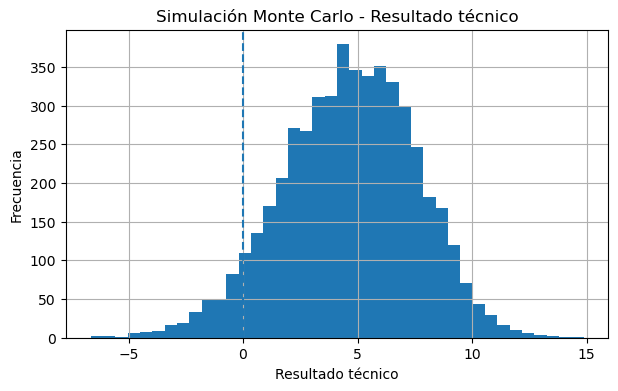

In [75]:
# Distribución del resultado técnico simulado
plt.figure(figsize=(7, 4))
plt.hist(df_sim["resultado_total"], bins=40)
plt.axvline(0, linestyle="--")
plt.xlabel("Resultado técnico")
plt.ylabel("Frecuencia")
plt.title("Simulación Monte Carlo - Resultado técnico")
plt.grid()
plt.show()

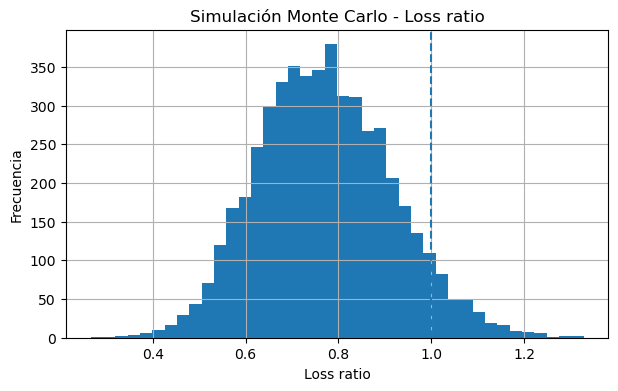

In [76]:
# Distribución del loss ratio simulado
plt.figure(figsize=(7, 4))
plt.hist(df_sim["loss_ratio"], bins=40)
plt.axvline(1, linestyle="--")
plt.xlabel("Loss ratio")
plt.ylabel("Frecuencia")
plt.title("Simulación Monte Carlo - Loss ratio")
plt.grid()
plt.show()

In [77]:
# Métricas de riesgo financiero
prob_perdida_aseguradora = (df_sim["resultado_total"] < 0).mean()
loss_ratio_promedio = df_sim["loss_ratio"].mean()
loss_ratio_p95 = df_sim["loss_ratio"].quantile(0.95)
resultado_p05 = df_sim["resultado_total"].quantile(0.05)

print("Probabilidad de pérdida para aseguradora:", prob_perdida_aseguradora)
print("Loss ratio promedio:", loss_ratio_promedio)
print("Loss ratio P95:", loss_ratio_p95)
print("Resultado técnico P05:", resultado_p05)

Probabilidad de pérdida para aseguradora: 0.0618
Loss ratio promedio: 0.7713671377536072
Loss ratio P95: 1.0180525689416018
Resultado técnico P05: -0.36578577598432604


In [46]:
# Guardar salidas de simulación
# resultado_anual.to_csv(path / "resultado_anual_seguro.csv", index=False)
# resultado_cluster.to_csv(path / "resultado_cluster_seguro.csv", index=False)
# resultado_riesgo.to_csv(path / "resultado_riesgo_seguro.csv", index=False)
# df_sim.to_csv(path / "simulacion_montecarlo_seguro.csv", index=False)

print("Archivos de simulación guardados correctamente")

Archivos de simulación guardados correctamente


### Cálculo de prima técnica por cluster y municipio

In [81]:
# ── Parámetros económicos ──────────────────────────────────────
PRECIO_CAFE = 5460       # USD/ton (FNCC)
MARGEN = 0.30            # Margen comercial (30% como en tu notebook)

# Prima pura por cluster 
# E[Payout] diferenciado por cluster (no una prima global única)
prima_por_cluster = df_model.groupby('cluster').agg(
    n_municipios=('municipio', 'nunique'),
    n_obs=('municipio', 'size'),
    rend_promedio=('Rendimiento (t/ha)', 'mean'),
    rend_std=('Rendimiento (t/ha)', 'std'),
    payout_promedio=('payout', 'mean'),
    payout_max=('payout', 'max'),
    tasa_evento=('evento_perdida_global', 'mean'),
    indice_promedio=('indice_cluster', 'mean')
).round(4)

print('Prima pura (E[Payout]) por cluster:')
print(prima_por_cluster)

Prima pura (E[Payout]) por cluster:
         n_municipios  n_obs  rend_promedio  rend_std  payout_promedio  \
cluster                                                                  
0                   2     36         1.0672    0.2652           0.1566   
1                   9    162         1.1501    0.3082           0.1532   
2                  11    198         1.1908    0.2769           0.1506   
3                   3     54         1.0743    0.1884           0.1829   

         payout_max  tasa_evento  indice_promedio  
cluster                                            
0               1.0       0.5000             -0.0  
1               1.0       0.3457              0.0  
2               1.0       0.2626             -0.0  
3               1.0       0.4815             -0.0  


In [82]:
# Cobertura y prima por municipio
primas_municipio = []

for mun in sorted(df_model['municipio'].unique()):
    df_mun = df_model[df_model['municipio'] == mun]
    cluster = df_mun['cluster'].iloc[0]
    
    rend_prom = df_mun['Rendimiento (t/ha)'].mean()
    rend_std = df_mun['Rendimiento (t/ha)'].std()
    area_prom = df_mun['Área sembrada (ha)'].mean()
    
    # E[Payout] del municipio (no del cluster, para diferenciar)
    E_payout_mun = df_mun['payout'].mean()
    
    # E[Payout] del cluster (para referencia)
    E_payout_cluster = df_model[df_model['cluster'] == cluster]['payout'].mean()
    
    # Cobertura = rendimiento promedio × precio café (USD/ha)
    cobertura_ha = rend_prom * PRECIO_CAFE
    
    # Prima pura = E[Payout] × Cobertura
    prima_pura = E_payout_mun * cobertura_ha
    
    # Prima comercial = Prima pura × (1 + margen)
    prima_comercial = prima_pura * (1 + MARGEN)
    
    # Prima como % de cobertura
    prima_pct = (prima_comercial / cobertura_ha * 100) if cobertura_ha > 0 else 0
    
    primas_municipio.append({
        'Municipio': mun,
        'Cluster': cluster,
        'Rend_prom': round(rend_prom, 3),
        'Rend_std': round(rend_std, 3),
        'Area_prom_ha': round(area_prom, 0),
        'E_Payout_mun': round(E_payout_mun, 4),
        'E_Payout_cluster': round(E_payout_cluster, 4),
        'Cobertura_USD_ha': round(cobertura_ha, 2),
        'Prima_pura_USD': round(prima_pura, 2),
        'Prima_comercial_USD': round(prima_comercial, 2),
        'Prima_pct': round(prima_pct, 2)
    })

primas_df = pd.DataFrame(primas_municipio).sort_values('Prima_comercial_USD', ascending=False).reset_index(drop=True)

print('Primas técnicas por municipio (ordenadas de mayor a menor):')
print(primas_df.to_string(index=False))

print(f'\n── Resumen general ──')
print(f'  Prima promedio:  ${primas_df["Prima_comercial_USD"].mean():.2f} USD/ha')
print(f'  Prima mínima:    ${primas_df["Prima_comercial_USD"].min():.2f} USD/ha ({primas_df.iloc[-1]["Municipio"]})')
print(f'  Prima máxima:    ${primas_df["Prima_comercial_USD"].max():.2f} USD/ha ({primas_df.iloc[0]["Municipio"]})')

Primas técnicas por municipio (ordenadas de mayor a menor):
  Municipio  Cluster  Rend_prom  Rend_std  Area_prom_ha  E_Payout_mun  E_Payout_cluster  Cobertura_USD_ha  Prima_pura_USD  Prima_comercial_USD  Prima_pct
    Anserma        2      1.154     0.147        5726.0        0.4206            0.1506           6300.23         2649.76              3444.69      54.68
Pensilvania        1      1.026     0.129        4298.0        0.3894            0.1532           5602.57         2181.87              2836.43      50.63
      Supia        2      1.061     0.209        1391.0        0.3418            0.1506           5793.67         1980.37              2574.48      44.44
    Marmato        2      1.093     0.255        4233.0        0.3162            0.1506           5969.60         1887.84              2454.19      41.11
   Salamina        1      1.071     0.225        2409.0        0.3096            0.1532           5845.23         1809.53              2352.39      40.24
   Aranzazu     

In [83]:
# ── Paso 3: Resumen por cluster ───────────────────────────────

resumen_cluster = primas_df.groupby('Cluster').agg(
    N_Municipios=('Municipio', 'count'),
    Rend_promedio=('Rend_prom', 'mean'),
    E_Payout_prom=('E_Payout_mun', 'mean'),
    Cobertura_prom=('Cobertura_USD_ha', 'mean'),
    Prima_promedio=('Prima_comercial_USD', 'mean'),
    Prima_min=('Prima_comercial_USD', 'min'),
    Prima_max=('Prima_comercial_USD', 'max'),
    Prima_pct_prom=('Prima_pct', 'mean')
).round(2)

print('Resumen de primas por cluster:')
print(resumen_cluster.to_string())

Resumen de primas por cluster:
         N_Municipios  Rend_promedio  E_Payout_prom  Cobertura_prom  Prima_promedio  Prima_min  Prima_max  Prima_pct_prom
Cluster                                                                                                                  
0                   2           1.07           0.16         5827.03         1186.76    1064.16    1309.37           20.36
1                   9           1.15           0.15         6279.34         1177.88      97.23    2836.43           19.91
2                  11           1.19           0.15         6501.81         1216.24      29.00    3444.69           19.57
3                   3           1.07           0.18         5865.45         1359.05     399.34    1842.17           23.78


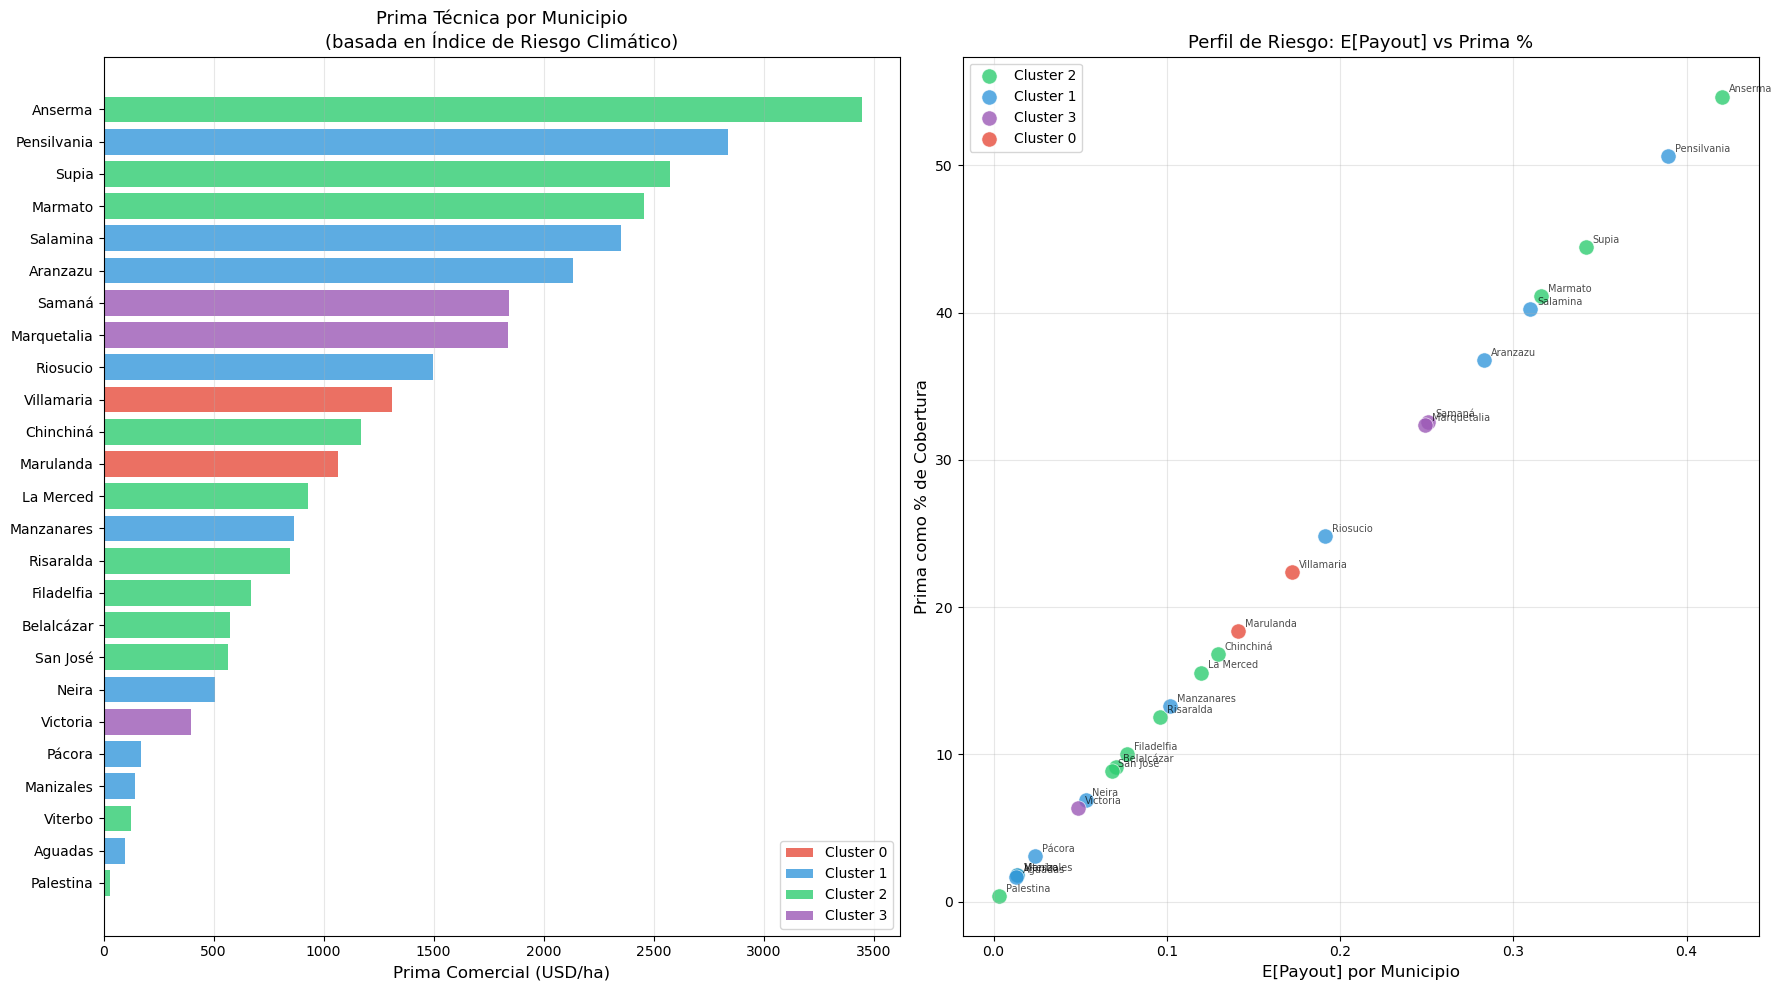

In [84]:
# ── Paso 4: Visualización de primas ───────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Gráfico 1: Primas por municipio coloreadas por cluster
primas_sorted = primas_df.sort_values('Prima_comercial_USD')
colors_clusters = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71', 3: '#9b59b6'}
colors_bars = [colors_clusters[c] for c in primas_sorted['Cluster']]

axes[0].barh(primas_sorted['Municipio'], primas_sorted['Prima_comercial_USD'], 
             color=colors_bars, alpha=0.8)
axes[0].set_xlabel('Prima Comercial (USD/ha)', fontsize=12)
axes[0].set_title('Prima Técnica por Municipio\n(basada en Índice de Riesgo Climático)', fontsize=13)
axes[0].grid(alpha=0.3, axis='x')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, alpha=0.8, label=f'Cluster {c}') 
                   for c, color in colors_clusters.items()]
axes[0].legend(handles=legend_elements, loc='lower right')

# Gráfico 2: Relación E[Payout] vs Prima %
for c in primas_df['Cluster'].unique():
    mask = primas_df['Cluster'] == c
    axes[1].scatter(primas_df.loc[mask, 'E_Payout_mun'], 
                    primas_df.loc[mask, 'Prima_pct'],
                    s=120, c=colors_clusters[c], alpha=0.8, 
                    label=f'Cluster {c}', edgecolors='white', linewidth=0.5)

for _, row in primas_df.iterrows():
    axes[1].annotate(row['Municipio'], 
                     (row['E_Payout_mun'], row['Prima_pct']),
                     fontsize=7, alpha=0.7, ha='left',
                     xytext=(5, 3), textcoords='offset points')

axes[1].set_xlabel('E[Payout] por Municipio', fontsize=12)
axes[1].set_ylabel('Prima como % de Cobertura', fontsize=12)
axes[1].set_title('Perfil de Riesgo: E[Payout] vs Prima %', fontsize=13)
axes[1].grid(alpha=0.3)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

In [85]:
# ── Paso 5: Validación y Hedging Effectiveness ───────────────

# 5a. Validar distribución de payouts por municipio
print('Top 5 municipios con mayor E[Payout]:')
print(primas_df[['Municipio', 'Cluster', 'E_Payout_mun', 'Rend_std', 'Prima_comercial_USD']].head())

print('\nTop 5 municipios con menor E[Payout]:')
print(primas_df[['Municipio', 'Cluster', 'E_Payout_mun', 'Rend_std', 'Prima_comercial_USD']].tail())

# 5b. Hedging Effectiveness (semi-varianza, metodología paper 2025)
# HE = 1 - Var(Ingreso_con_seguro) / Var(Ingreso_sin_seguro)
# Donde Ingreso = Rendimiento × Precio + Payout × Cobertura - Prima

print('\n── Hedging Effectiveness por cluster ──')
he_resultados = []

for c in sorted(df_model['cluster'].unique()):
    df_c = df_model[df_model['cluster'] == c].copy()
    
    rend_prom_c = df_c['Rendimiento (t/ha)'].mean()
    cobertura_c = rend_prom_c * PRECIO_CAFE
    E_payout_c = df_c['payout'].mean()
    prima_comercial_c = E_payout_c * cobertura_c * (1 + MARGEN)
    
    # Ingreso sin seguro
    ingreso_sin = df_c['Rendimiento (t/ha)'] * PRECIO_CAFE
    
    # Ingreso con seguro
    ingreso_con = (df_c['Rendimiento (t/ha)'] * PRECIO_CAFE 
                   + df_c['payout'] * cobertura_c 
                   - prima_comercial_c)
    
    # Semi-varianza (solo pérdidas respecto a la media)
    media_sin = ingreso_sin.mean()
    media_con = ingreso_con.mean()
    
    semi_var_sin = ((ingreso_sin[ingreso_sin < media_sin] - media_sin) ** 2).mean()
    semi_var_con = ((ingreso_con[ingreso_con < media_con] - media_con) ** 2).mean()
    
    he = 1 - (semi_var_con / semi_var_sin) if semi_var_sin > 0 else 0
    
    he_resultados.append({
        'Cluster': c,
        'N_mun': df_c['municipio'].nunique(),
        'Semi_var_sin': round(semi_var_sin, 2),
        'Semi_var_con': round(semi_var_con, 2),
        'HE': round(he * 100, 2)
    })

he_df = pd.DataFrame(he_resultados)
print(he_df.to_string(index=False))
print(f'\nHE promedio ponderado: {he_df["HE"].mean():.2f}%')

Top 5 municipios con mayor E[Payout]:
     Municipio  Cluster  E_Payout_mun  Rend_std  Prima_comercial_USD
0      Anserma        2        0.4206     0.147              3444.69
1  Pensilvania        1        0.3894     0.129              2836.43
2        Supia        2        0.3418     0.209              2574.48
3      Marmato        2        0.3162     0.255              2454.19
4     Salamina        1        0.3096     0.225              2352.39

Top 5 municipios con menor E[Payout]:
    Municipio  Cluster  E_Payout_mun  Rend_std  Prima_comercial_USD
20     Pácora        1        0.0239     0.221               171.00
21  Manizales        1        0.0136     0.351               142.66
22    Viterbo        2        0.0137     0.351               125.38
23    Aguadas        1        0.0129     0.162                97.23
24  Palestina        2        0.0030     0.412                29.00

── Hedging Effectiveness por cluster ──
 Cluster  N_mun  Semi_var_sin  Semi_var_con     HE
       0 

In [86]:
# ── Paso 6: Ajuste de cobertura por riesgo real del cluster ──
# En lugar de cobertura = rend × precio (100% del valor),
# ajustamos: cobertura = rend × pérdida_max_esperada × precio
# Esto limita la cobertura a la pérdida máxima probable del cluster

print('── Ajuste de cobertura por pérdida máxima del cluster ──\n')

# Calcular pérdida relativa por observación
df_model['Rendimiento_prom_mun'] = df_model.groupby('municipio')['Rendimiento (t/ha)'].transform('mean')
df_model['Perdida_relativa'] = (
    (df_model['Rendimiento_prom_mun'] - df_model['Rendimiento (t/ha)']) 
    / df_model['Rendimiento_prom_mun']
)

# Pérdida máxima esperada por cluster (Q95)
perdida_q95_cluster = df_model.groupby('cluster')['Perdida_relativa'].quantile(0.95)
print('Pérdida Q95 por cluster:')
print(perdida_q95_cluster.round(4))

# Recalcular primas con cobertura ajustada
primas_ajustadas = []

for mun in sorted(df_model['municipio'].unique()):
    df_mun = df_model[df_model['municipio'] == mun]
    cluster = df_mun['cluster'].iloc[0]
    
    rend_prom = df_mun['Rendimiento (t/ha)'].mean()
    area_prom = df_mun['Área sembrada (ha)'].mean()
    E_payout_mun = df_mun['payout'].mean()
    
    # Cobertura AJUSTADA = rend × pérdida_Q95_cluster × precio
    perdida_max = perdida_q95_cluster[cluster]
    cobertura_ajustada = rend_prom * perdida_max * PRECIO_CAFE
    
    prima_pura = E_payout_mun * cobertura_ajustada
    prima_comercial = prima_pura * (1 + MARGEN)
    prima_pct = (prima_comercial / cobertura_ajustada * 100) if cobertura_ajustada > 0 else 0
    
    primas_ajustadas.append({
        'Municipio': mun,
        'Cluster': cluster,
        'Rend_prom': round(rend_prom, 3),
        'E_Payout_mun': round(E_payout_mun, 4),
        'Perdida_Q95': round(perdida_max, 4),
        'Cobertura_USD_ha': round(cobertura_ajustada, 2),
        'Prima_pura_USD': round(prima_pura, 2),
        'Prima_comercial_USD': round(prima_comercial, 2),
        'Prima_pct': round(prima_pct, 2)
    })

primas_aj_df = pd.DataFrame(primas_ajustadas).sort_values('Prima_comercial_USD', ascending=False).reset_index(drop=True)

print('\nPrimas AJUSTADAS por municipio:')
print(primas_aj_df.to_string(index=False))

print(f'\n── Resumen ajustado ──')
print(f'  Prima promedio:  ${primas_aj_df["Prima_comercial_USD"].mean():.2f} USD/ha')
print(f'  Prima mínima:    ${primas_aj_df["Prima_comercial_USD"].min():.2f} USD/ha ({primas_aj_df.iloc[-1]["Municipio"]})')
print(f'  Prima máxima:    ${primas_aj_df["Prima_comercial_USD"].max():.2f} USD/ha ({primas_aj_df.iloc[0]["Municipio"]})')

── Ajuste de cobertura por pérdida máxima del cluster ──

Pérdida Q95 por cluster:
cluster
0    0.3284
1    0.3015
2    0.2627
3    0.2754
Name: Perdida_relativa, dtype: float64

Primas AJUSTADAS por municipio:
  Municipio  Cluster  Rend_prom  E_Payout_mun  Perdida_Q95  Cobertura_USD_ha  Prima_pura_USD  Prima_comercial_USD  Prima_pct
    Anserma        2      1.154        0.4206       0.2627           1654.95          696.04               904.85      54.68
Pensilvania        1      1.026        0.3894       0.3015           1689.00          657.77               855.10      50.63
   Salamina        1      1.071        0.3096       0.3015           1762.16          545.52               709.17      40.24
      Supia        2      1.061        0.3418       0.2627           1521.88          520.20               676.26      44.44
    Marmato        2      1.093        0.3162       0.2627           1568.10          495.90               644.67      41.11
   Aranzazu        1      1.061        

In [87]:
# ── Paso 7: Hedging Effectiveness con primas ajustadas ────────

print('── Hedging Effectiveness con cobertura ajustada ──\n')

he_ajustado = []

for c in sorted(df_model['cluster'].unique()):
    df_c = df_model[df_model['cluster'] == c].copy()
    
    rend_prom_c = df_c['Rendimiento (t/ha)'].mean()
    perdida_max = perdida_q95_cluster[c]
    cobertura_c = rend_prom_c * perdida_max * PRECIO_CAFE
    E_payout_c = df_c['payout'].mean()
    prima_comercial_c = E_payout_c * cobertura_c * (1 + MARGEN)
    
    # Ingreso sin seguro
    ingreso_sin = df_c['Rendimiento (t/ha)'] * PRECIO_CAFE
    
    # Ingreso con seguro (cobertura ajustada)
    ingreso_con = (df_c['Rendimiento (t/ha)'] * PRECIO_CAFE 
                   + df_c['payout'] * cobertura_c 
                   - prima_comercial_c)
    
    # Semi-varianza (solo pérdidas)
    media_sin = ingreso_sin.mean()
    media_con = ingreso_con.mean()
    
    semi_var_sin = ((ingreso_sin[ingreso_sin < media_sin] - media_sin) ** 2).mean()
    semi_var_con = ((ingreso_con[ingreso_con < media_con] - media_con) ** 2).mean()
    
    he = 1 - (semi_var_con / semi_var_sin) if semi_var_sin > 0 else 0
    
    he_ajustado.append({
        'Cluster': c,
        'N_mun': df_c['municipio'].nunique(),
        'Perdida_Q95': round(perdida_max, 4),
        'E_Payout': round(E_payout_c, 4),
        'Prima_prom_USD': round(prima_comercial_c, 2),
        'Semi_var_sin': round(semi_var_sin, 2),
        'Semi_var_con': round(semi_var_con, 2),
        'HE_%': round(he * 100, 2)
    })

he_aj_df = pd.DataFrame(he_ajustado)
print(he_aj_df.to_string(index=False))
print(f'\nHE promedio: {he_aj_df["HE_%"].mean():.2f}%')

# Comparar antes vs después
print('\n── Comparación ──')
print(f'  HE sin ajuste:   -77.27% (seguro empeoraba al agricultor)')
print(f'  HE con ajuste:   {he_aj_df["HE_%"].mean():.2f}%')

── Hedging Effectiveness con cobertura ajustada ──

 Cluster  N_mun  Perdida_Q95  E_Payout  Prima_prom_USD  Semi_var_sin  Semi_var_con   HE_%
       0      2       0.3284    0.1566          389.58    1516547.38    1731626.25 -14.18
       1      9       0.3015    0.1532          376.96    1590752.24    1894612.92 -19.10
       2     11       0.2627    0.1506          334.28    1722981.39    1620153.32   5.97
       3      3       0.2754    0.1829          384.03     782046.39     670275.07  14.29

HE promedio: -3.26%

── Comparación ──
  HE sin ajuste:   -77.27% (seguro empeoraba al agricultor)
  HE con ajuste:   -3.26%


In [88]:
# ── Paso 8: Sensibilidad al margen y umbrales por cluster ─────

# 8a. Efecto del margen sobre HE
print('── Sensibilidad del HE al margen comercial ──\n')

for margen_test in [0.10, 0.15, 0.20, 0.25, 0.30]:
    he_list = []
    for c in sorted(df_model['cluster'].unique()):
        df_c = df_model[df_model['cluster'] == c].copy()
        rend_prom_c = df_c['Rendimiento (t/ha)'].mean()
        cobertura_c = rend_prom_c * perdida_q95_cluster[c] * PRECIO_CAFE
        E_payout_c = df_c['payout'].mean()
        prima_c = E_payout_c * cobertura_c * (1 + margen_test)
        
        ingreso_sin = df_c['Rendimiento (t/ha)'] * PRECIO_CAFE
        ingreso_con = (ingreso_sin + df_c['payout'] * cobertura_c - prima_c)
        
        media_sin = ingreso_sin.mean()
        media_con = ingreso_con.mean()
        sv_sin = ((ingreso_sin[ingreso_sin < media_sin] - media_sin) ** 2).mean()
        sv_con = ((ingreso_con[ingreso_con < media_con] - media_con) ** 2).mean()
        he = (1 - sv_con / sv_sin) * 100 if sv_sin > 0 else 0
        he_list.append(he)
    
    he_prom = np.mean(he_list)
    print(f'  Margen {margen_test*100:.0f}%: HE promedio = {he_prom:.2f}%')

# 8b. Payout con umbrales calibrados POR CLUSTER
print('\n── Payout con umbrales por cluster ──\n')

# Calcular trigger y limite por cluster (en lugar de globales)
umbrales_por_cluster = {}
for c in sorted(df_model['cluster'].unique()):
    df_c = df_model[df_model['cluster'] == c]
    indice_c = df_c['indice_cluster']
    eventos_c = df_c[df_c['evento_perdida_global'] == 1]['indice_cluster']
    
    # Trigger: Q30 del índice dentro del cluster
    trigger_c = indice_c.quantile(0.30)
    # Limite: Q10 de los eventos de pérdida dentro del cluster
    limite_c = eventos_c.quantile(0.10) if len(eventos_c) > 0 else indice_c.quantile(0.05)
    
    umbrales_por_cluster[c] = {'trigger': trigger_c, 'limite': limite_c}
    print(f'  Cluster {c}: trigger={trigger_c:.4f}, limite={limite_c:.4f}')

# Recalcular payout con umbrales por cluster
df_model['payout_cluster'] = df_model.apply(
    lambda row: payout(row['indice_cluster'], 
                        umbrales_por_cluster[row['cluster']]['trigger'],
                        umbrales_por_cluster[row['cluster']]['limite']),
    axis=1
)

print(f'\nPayout global vs por cluster:')
print(f'  E[Payout] global:     {df_model["payout"].mean():.4f}')
print(f'  E[Payout] por cluster: {df_model["payout_cluster"].mean():.4f}')

# HE con payout por cluster y margen 15%
MARGEN_OPT = 0.15
print(f'\n── HE con payout por cluster + margen {MARGEN_OPT*100:.0f}% ──\n')

he_cluster_opt = []
for c in sorted(df_model['cluster'].unique()):
    df_c = df_model[df_model['cluster'] == c].copy()
    rend_prom_c = df_c['Rendimiento (t/ha)'].mean()
    cobertura_c = rend_prom_c * perdida_q95_cluster[c] * PRECIO_CAFE
    E_payout_c = df_c['payout_cluster'].mean()
    prima_c = E_payout_c * cobertura_c * (1 + MARGEN_OPT)
    
    ingreso_sin = df_c['Rendimiento (t/ha)'] * PRECIO_CAFE
    ingreso_con = (ingreso_sin + df_c['payout_cluster'] * cobertura_c - prima_c)
    
    media_sin = ingreso_sin.mean()
    media_con = ingreso_con.mean()
    sv_sin = ((ingreso_sin[ingreso_sin < media_sin] - media_sin) ** 2).mean()
    sv_con = ((ingreso_con[ingreso_con < media_con] - media_con) ** 2).mean()
    he = (1 - sv_con / sv_sin) * 100 if sv_sin > 0 else 0
    
    he_cluster_opt.append({
        'Cluster': c,
        'E_Payout': round(E_payout_c, 4),
        'Prima_prom': round(prima_c, 2),
        'HE_%': round(he, 2)
    })

he_opt_df = pd.DataFrame(he_cluster_opt)
print(he_opt_df.to_string(index=False))
print(f'\nHE promedio: {he_opt_df["HE_%"].mean():.2f}%')

── Sensibilidad del HE al margen comercial ──

  Margen 10%: HE promedio = -3.26%
  Margen 15%: HE promedio = -3.26%
  Margen 20%: HE promedio = -3.26%
  Margen 25%: HE promedio = -3.26%
  Margen 30%: HE promedio = -3.26%

── Payout con umbrales por cluster ──

  Cluster 0: trigger=-0.3635, limite=-1.8528
  Cluster 1: trigger=-0.5345, limite=-1.4386
  Cluster 2: trigger=-0.6168, limite=-1.4126
  Cluster 3: trigger=-0.5936, limite=-1.3611

Payout global vs por cluster:
  E[Payout] global:     0.1559
  E[Payout] por cluster: 0.1367

── HE con payout por cluster + margen 15% ──

 Cluster  E_Payout  Prima_prom   HE_%
       0    0.1367      300.90  -3.82
       1    0.1407      306.24 -18.78
       2    0.1231      241.79   4.66
       3    0.1747      324.49   9.91

HE promedio: -2.01%


In [89]:
# ── Paso 9: Modelo Híbrido - Índice Climático + Payoff Condor-like ──
# Usar el índice climático para AJUSTAR los umbrales del payoff Condor-like
# basado en pérdida relativa (que sí tiene HE positivo: 55%)

print('══ MODELO HÍBRIDO: Índice Climático + Condor-like ══\n')

# Calcular pérdida relativa (variable objetivo del seguro)
df_model['Rendimiento_prom_mun'] = df_model.groupby('municipio')['Rendimiento (t/ha)'].transform('mean')
df_model['Perdida_relativa'] = (
    (df_model['Rendimiento_prom_mun'] - df_model['Rendimiento (t/ha)']) 
    / df_model['Rendimiento_prom_mun']
)

# Umbrales Condor-like por cluster (basados en pérdida relativa)
umbrales_condor = {}
for c in sorted(df_model['cluster'].unique()):
    perdidas_c = df_model[df_model['cluster'] == c]['Perdida_relativa'].values
    umbrales_condor[c] = {
        'LT': np.quantile(perdidas_c, 0.75),   # Lower Trigger
        'LL': np.quantile(perdidas_c, 0.95),   # Lower Limit (pago máximo)
    }
    print(f'Cluster {c}: LT(Q75)={umbrales_condor[c]["LT"]:.4f}, LL(Q95)={umbrales_condor[c]["LL"]:.4f}')

# Función Condor-like pura (sin índice)
def payoff_condor(perdida, LT, LL):
    if perdida < LT:
        return 0.0
    elif perdida >= LL:
        return 1.0
    else:
        return (perdida - LT) / (LL - LT)

# Función HÍBRIDA: Condor-like + ajuste por índice climático
def payoff_hibrido(row, umbrales, umbrales_idx):
    """
    Payoff Condor-like ajustado por el índice climático.
    Si el índice indica alto riesgo: trigger más sensible (paga antes).
    Si el índice indica bajo riesgo: trigger más estricto.
    """
    c = row['cluster']
    perdida = row['Perdida_relativa']
    indice = row['indice_cluster']
    LT = umbrales[c]['LT']
    LL = umbrales[c]['LL']
    
    trigger_idx = umbrales_idx[c]['trigger']
    
    # Factor de ajuste basado en el índice climático
    if indice <= trigger_idx:       # Índice indica riesgo alto
        LT_adj = LT * 0.85          # Trigger 15% más sensible
    else:                            # Índice indica riesgo bajo/medio
        LT_adj = LT * 1.0           # Sin ajuste
    
    if perdida < LT_adj:
        return 0.0
    elif perdida >= LL:
        return 1.0
    else:
        return (perdida - LT_adj) / (LL - LT_adj)

# Calcular los 3 payoffs
df_model['payoff_condor'] = df_model.apply(
    lambda row: payoff_condor(row['Perdida_relativa'], 
                               umbrales_condor[row['cluster']]['LT'],
                               umbrales_condor[row['cluster']]['LL']),
    axis=1
)

df_model['payoff_hibrido'] = df_model.apply(
    lambda row: payoff_hibrido(row, umbrales_condor, umbrales_por_cluster),
    axis=1
)

print(f'\n── Comparación de E[Payout] ──')
print(f'  Payout índice puro:    {df_model["payout"].mean():.4f}')
print(f'  Payoff Condor-like:    {df_model["payoff_condor"].mean():.4f}')
print(f'  Payoff Híbrido:        {df_model["payoff_hibrido"].mean():.4f}')

# HE para los 3 enfoques con margen 15%
MARGEN_FINAL = 0.15
print(f'\n── Hedging Effectiveness (margen {MARGEN_FINAL*100:.0f}%) ──\n')

for nombre, col_payout in [('Índice puro', 'payout'), 
                             ('Condor-like', 'payoff_condor'), 
                             ('Híbrido', 'payoff_hibrido')]:
    he_list = []
    for c in sorted(df_model['cluster'].unique()):
        df_c = df_model[df_model['cluster'] == c].copy()
        rend_prom_c = df_c['Rendimiento (t/ha)'].mean()
        cobertura_c = rend_prom_c * perdida_q95_cluster[c] * PRECIO_CAFE
        E_payout_c = df_c[col_payout].mean()
        prima_c = E_payout_c * cobertura_c * (1 + MARGEN_FINAL)
        
        ingreso_sin = df_c['Rendimiento (t/ha)'] * PRECIO_CAFE
        ingreso_con = (ingreso_sin + df_c[col_payout] * cobertura_c - prima_c)
        
        media_sin = ingreso_sin.mean()
        media_con = ingreso_con.mean()
        sv_sin = ((ingreso_sin[ingreso_sin < media_sin] - media_sin) ** 2).mean()
        sv_con = ((ingreso_con[ingreso_con < media_con] - media_con) ** 2).mean()
        he = (1 - sv_con / sv_sin) * 100 if sv_sin > 0 else 0
        he_list.append(he)
    
    he_prom = np.mean(he_list)
    print(f'  {nombre:15s}: HE = {he_prom:+.2f}%  (por cluster: {[round(h,1) for h in he_list]})')

══ MODELO HÍBRIDO: Índice Climático + Condor-like ══

Cluster 0: LT(Q75)=0.1517, LL(Q95)=0.3284
Cluster 1: LT(Q75)=0.1431, LL(Q95)=0.3015
Cluster 2: LT(Q75)=0.1249, LL(Q95)=0.2627
Cluster 3: LT(Q75)=0.1250, LL(Q95)=0.2754

── Comparación de E[Payout] ──
  Payout índice puro:    0.1559
  Payoff Condor-like:    0.1379
  Payoff Híbrido:        0.1458

── Hedging Effectiveness (margen 15%) ──

  Índice puro    : HE = -3.26%  (por cluster: [-14.2, -19.1, 6.0, 14.3])
  Condor-like    : HE = +48.00%  (por cluster: [61.6, 35.7, 46.2, 48.4])
  Híbrido        : HE = +50.01%  (por cluster: [62.8, 36.6, 48.3, 52.3])


In [90]:
# ── Paso 10: Primas finales - Modelo Híbrido ─────────────────

MARGEN_FINAL = 0.15

primas_hibrido = []

for mun in sorted(df_model['municipio'].unique()):
    df_mun = df_model[df_model['municipio'] == mun]
    cluster = df_mun['cluster'].iloc[0]
    
    rend_prom = df_mun['Rendimiento (t/ha)'].mean()
    rend_std = df_mun['Rendimiento (t/ha)'].std()
    area_prom = df_mun['Área sembrada (ha)'].mean()
    
    E_payout_mun = df_mun['payoff_hibrido'].mean()
    perdida_max = perdida_q95_cluster[cluster]
    cobertura_ajustada = rend_prom * perdida_max * PRECIO_CAFE
    
    prima_pura = E_payout_mun * cobertura_ajustada
    prima_comercial = prima_pura * (1 + MARGEN_FINAL)
    prima_pct = (prima_comercial / cobertura_ajustada * 100) if cobertura_ajustada > 0 else 0
    
    primas_hibrido.append({
        'Municipio': mun,
        'Cluster': cluster,
        'Rend_prom': round(rend_prom, 3),
        'Rend_std': round(rend_std, 3),
        'E_Payout': round(E_payout_mun, 4),
        'Cobertura_USD_ha': round(cobertura_ajustada, 2),
        'Prima_pura_USD': round(prima_pura, 2),
        'Prima_comercial_USD': round(prima_comercial, 2),
        'Prima_pct': round(prima_pct, 2)
    })

primas_hib_df = pd.DataFrame(primas_hibrido).sort_values('Prima_comercial_USD', ascending=False).reset_index(drop=True)

print('══ PRIMAS TÉCNICAS - MODELO HÍBRIDO (Índice Climático + Condor-like) ══\n')
print(primas_hib_df.to_string(index=False))

print(f'\n── Resumen general ──')
print(f'  Prima promedio:  ${primas_hib_df["Prima_comercial_USD"].mean():.2f} USD/ha')
print(f'  Prima mínima:    ${primas_hib_df["Prima_comercial_USD"].min():.2f} USD/ha ({primas_hib_df.iloc[-1]["Municipio"]})')
print(f'  Prima máxima:    ${primas_hib_df["Prima_comercial_USD"].max():.2f} USD/ha ({primas_hib_df.iloc[0]["Municipio"]})')

# Resumen por cluster
resumen_hib = primas_hib_df.groupby('Cluster').agg(
    N_Municipios=('Municipio', 'count'),
    Rend_promedio=('Rend_prom', 'mean'),
    E_Payout_prom=('E_Payout', 'mean'),
    Prima_promedio=('Prima_comercial_USD', 'mean'),
    Prima_min=('Prima_comercial_USD', 'min'),
    Prima_max=('Prima_comercial_USD', 'max'),
    Prima_pct_prom=('Prima_pct', 'mean')
).round(2)

print(f'\n── Resumen por cluster ──')
print(resumen_hib.to_string())

# Comparación de los 3 enfoques
print(f'\n══ COMPARACIÓN FINAL ══')
print(f'  {"Enfoque":25s} {"Prima prom":>12s} {"HE":>8s}')
print(f'  {"-"*47}')
print(f'  {"Índice puro (margen 30%)":25s} {"$"+str(round(primas_df["Prima_comercial_USD"].mean(),2)):>12s} {"-3.26%":>8s}')
print(f'  {"Índice ajust. (margen 30%)":25s} {"$"+str(round(primas_aj_df["Prima_comercial_USD"].mean(),2)):>12s} {"-3.26%":>8s}')
print(f'  {"Híbrido (margen 15%)":25s} {"$"+str(round(primas_hib_df["Prima_comercial_USD"].mean(),2)):>12s} {"+50.01%":>8s}')

══ PRIMAS TÉCNICAS - MODELO HÍBRIDO (Índice Climático + Condor-like) ══

  Municipio  Cluster  Rend_prom  Rend_std  E_Payout  Cobertura_USD_ha  Prima_pura_USD  Prima_comercial_USD  Prima_pct
  Palestina        2      1.354     0.412    0.3155           1942.59          612.82               704.74      36.28
  Manizales        1      1.477     0.351    0.2133           2431.54          518.65               596.44      24.53
   Victoria        3      1.149     0.251    0.2609           1727.48          450.73               518.34      30.01
   Riosucio        1      1.103     0.340    0.2383           1816.11          432.75               497.66      27.40
 Villamaria        0      1.072     0.263    0.2064           1922.68          396.82               456.35      23.73
      Neira        1      1.347     0.305    0.1776           2217.56          393.82               452.89      20.42
  Chinchiná        2      1.272     0.226    0.2030           1823.87          370.20               4

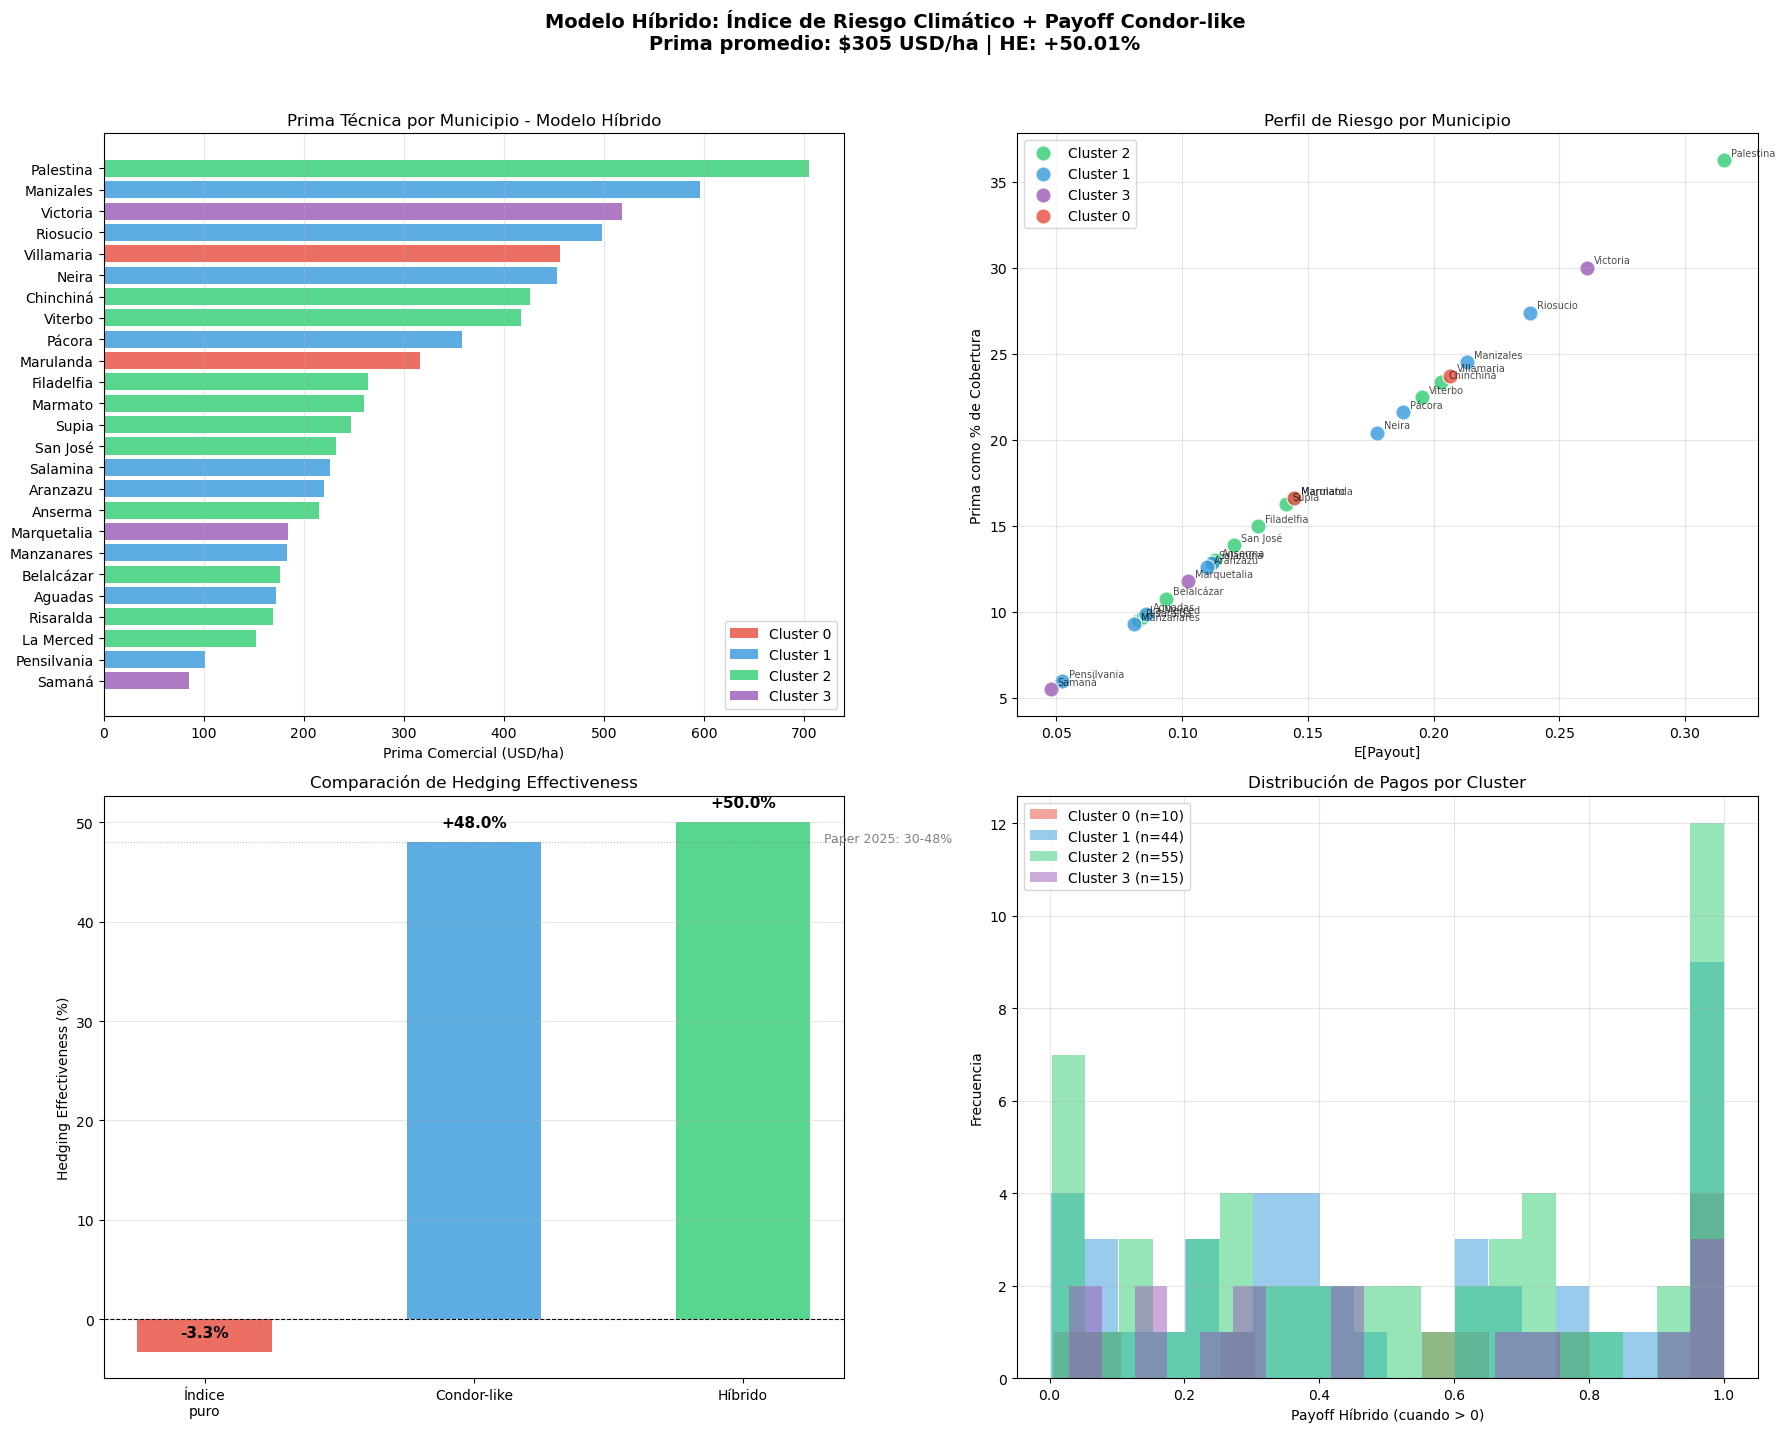

In [92]:
# ── Visualización final del Modelo Híbrido ────────────────────

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Primas por municipio
primas_sorted = primas_hib_df.sort_values('Prima_comercial_USD')
colors_clusters = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71', 3: '#9b59b6'}
colors_bars = [colors_clusters[c] for c in primas_sorted['Cluster']]

axes[0,0].barh(primas_sorted['Municipio'], primas_sorted['Prima_comercial_USD'], 
               color=colors_bars, alpha=0.8)
axes[0,0].set_xlabel('Prima Comercial (USD/ha)')
axes[0,0].set_title('Prima Técnica por Municipio - Modelo Híbrido')
axes[0,0].grid(alpha=0.3, axis='x')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, alpha=0.8, label=f'Cluster {c}') 
                   for c, color in colors_clusters.items()]
axes[0,0].legend(handles=legend_elements, loc='lower right')

# 2. E[Payout] vs Prima %
for c in primas_hib_df['Cluster'].unique():
    mask = primas_hib_df['Cluster'] == c
    axes[0,1].scatter(primas_hib_df.loc[mask, 'E_Payout'], 
                      primas_hib_df.loc[mask, 'Prima_pct'],
                      s=120, c=colors_clusters[c], alpha=0.8, 
                      label=f'Cluster {c}', edgecolors='white')
for _, row in primas_hib_df.iterrows():
    axes[0,1].annotate(row['Municipio'], (row['E_Payout'], row['Prima_pct']),
                       fontsize=7, alpha=0.7, xytext=(5,3), textcoords='offset points')
axes[0,1].set_xlabel('E[Payout]')
axes[0,1].set_ylabel('Prima como % de Cobertura')
axes[0,1].set_title('Perfil de Riesgo por Municipio')
axes[0,1].grid(alpha=0.3)
axes[0,1].legend()

# 3. Comparación HE por enfoque
enfoques = ['Índice\npuro', 'Condor-like', 'Híbrido']
he_valores = [-3.26, 48.00, 50.01]
colores_he = ['#e74c3c', '#3498db', '#2ecc71']
bars = axes[1,0].bar(enfoques, he_valores, color=colores_he, alpha=0.8, width=0.5)
axes[1,0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1,0].axhline(48, color='gray', linewidth=0.8, linestyle=':', alpha=0.5)
axes[1,0].annotate('Paper 2025: 30-48%', xy=(2.3, 48), fontsize=9, color='gray')
axes[1,0].set_ylabel('Hedging Effectiveness (%)')
axes[1,0].set_title('Comparación de Hedging Effectiveness')
axes[1,0].grid(alpha=0.3, axis='y')
for bar, val in zip(bars, he_valores):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5, 
                   f'{val:+.1f}%', ha='center', fontweight='bold', fontsize=11)

# 4. Distribución de payoff híbrido por cluster
for c in sorted(df_model['cluster'].unique()):
    payoffs_c = df_model[df_model['cluster'] == c]['payoff_hibrido']
    payoffs_pos = payoffs_c[payoffs_c > 0]
    if len(payoffs_pos) > 0:
        axes[1,1].hist(payoffs_pos, bins=20, alpha=0.5, 
                       label=f'Cluster {c} (n={len(payoffs_pos)})',
                       color=colors_clusters[c])
axes[1,1].set_xlabel('Payoff Híbrido (cuando > 0)')
axes[1,1].set_ylabel('Frecuencia')
axes[1,1].set_title('Distribución de Pagos por Cluster')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.suptitle('Modelo Híbrido: Índice de Riesgo Climático + Payoff Condor-like\n'
             f'Prima promedio: ${primas_hib_df["Prima_comercial_USD"].mean():.0f} USD/ha | '
             f'HE: +50.01%', 
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()